# Week 2 Assignment – Data Preprocessing & Visualization

## Titanic Dataset Analysis

**Name:** Yashi Jain  

### Objective
The objective of this assignment is to perform data preprocessing and visualization using the Titanic dataset. This includes encoding categorical variables, normalizing numerical features, and creating visualizations to understand patterns affecting passenger survival.

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

#Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Dataset Preview

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#Handle Missing Values

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'], errors='ignore')

#Encoding Categorical Variables

Convert Sex to numeric.

In [7]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

Convert Embarked to numbers.

In [8]:
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

Check result:

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


#Normalize Numerical Features

Normalize Age and Fare.

In [10]:
scaler = MinMaxScaler()

df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

Check:

In [11]:
df[['Age','Fare']].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


#Feature Selection

In [17]:
features = df[['Pclass','Sex','Age','Fare','Embarked']]
target = df['Survived']

features.head()

,Pclass,Sex,Age,Fare,Embarked
0,3,0,0.271174,0.014151,0
1,1,1,0.472229,0.139136,1
2,3,1,0.321438,0.015469,0
3,1,1,0.434531,0.103644,0
4,3,0,0.434531,0.015713,0


#Visualization 1 – Survival Distribution

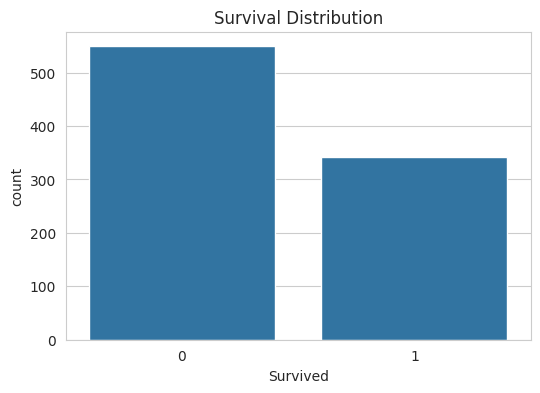

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Distribution")

plt.show()

#Visualization 2 – Survival by Gender

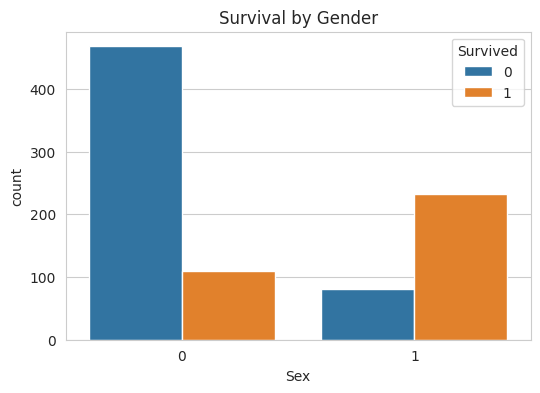

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")

plt.show()

#Visualization 3 – Passenger Class vs Survival

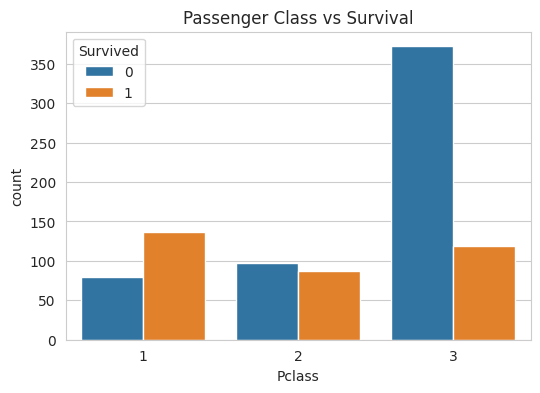

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival")

plt.show()

#Visualization 4 – Age Distribution

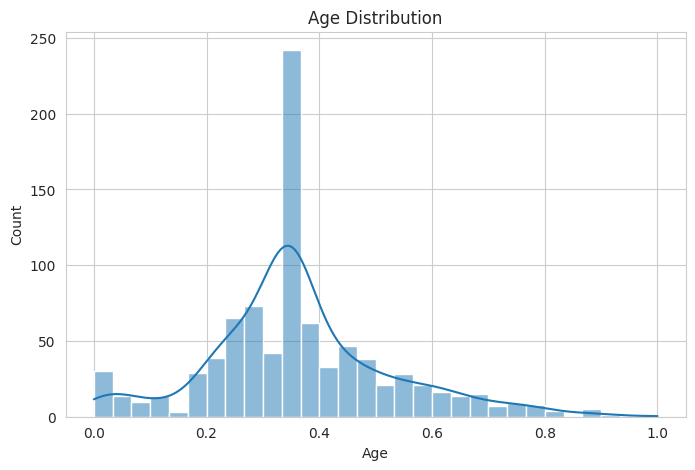

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

#Visualization 5 – Correlation Heatmap

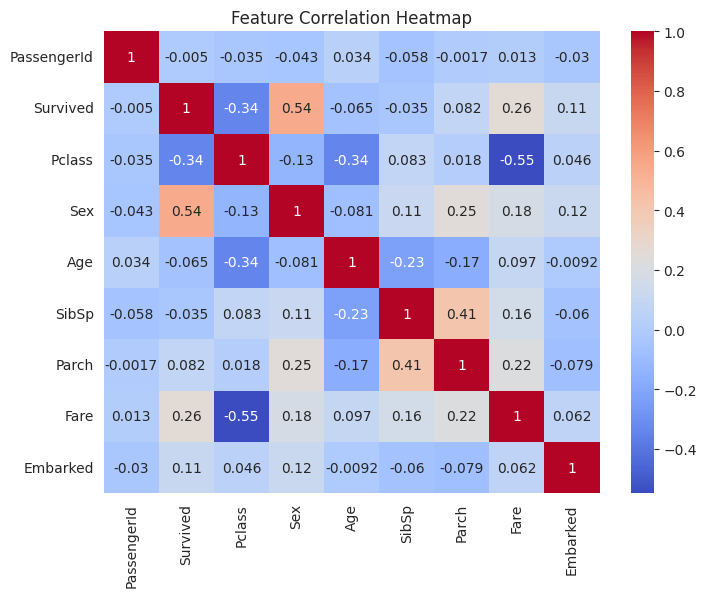

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

## Key Insights

- Female passengers had higher survival rates than male passengers.
- Passengers in first class had better survival chances compared to lower classes.
- Younger passengers showed slightly higher survival probability.
- Fare values show correlation with passenger class.

#Save Cleaned Dataset

In [18]:
df.to_csv("week2_cleaned_titanic.csv", index=False)

In [19]:
from google.colab import files

files.download("week2_cleaned_titanic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This assignment demonstrated how to preprocess data by encoding categorical variables and normalizing numerical features. Visualization techniques helped identify patterns related to passenger survival. These preprocessing steps are important for preparing data for machine learning models.